In [102]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [103]:
surnames = open("../data/surnames_hy.txt", "r", encoding="utf-8").read().splitlines()
surnames[:3]

['աբազյան', 'աբալակով', 'աբալյան']

In [104]:
len(surnames)

689

In [105]:
chars = sorted(list(set(''.join(surnames))))
chars[:5]

['ա', 'բ', 'գ', 'դ', 'ե']

In [106]:
dataset_len = len(chars)

In [107]:
char_to_num = {s:i+1 for i,s in enumerate(chars)}
char_to_num['.'] = 0
num_to_char = {i:s for s,i in char_to_num.items()}
print(num_to_char)
print(char_to_num)

{1: 'ա', 2: 'բ', 3: 'գ', 4: 'դ', 5: 'ե', 6: 'զ', 7: 'է', 8: 'թ', 9: 'ժ', 10: 'ի', 11: 'լ', 12: 'խ', 13: 'ծ', 14: 'կ', 15: 'հ', 16: 'ձ', 17: 'ղ', 18: 'ճ', 19: 'մ', 20: 'յ', 21: 'ն', 22: 'շ', 23: 'ո', 24: 'չ', 25: 'պ', 26: 'ջ', 27: 'ռ', 28: 'ս', 29: 'վ', 30: 'տ', 31: 'ր', 32: 'ց', 33: 'ւ', 34: 'փ', 35: 'ք', 36: 'օ', 37: 'ֆ', 38: 'և', 0: '.'}
{'ա': 1, 'բ': 2, 'գ': 3, 'դ': 4, 'ե': 5, 'զ': 6, 'է': 7, 'թ': 8, 'ժ': 9, 'ի': 10, 'լ': 11, 'խ': 12, 'ծ': 13, 'կ': 14, 'հ': 15, 'ձ': 16, 'ղ': 17, 'ճ': 18, 'մ': 19, 'յ': 20, 'ն': 21, 'շ': 22, 'ո': 23, 'չ': 24, 'պ': 25, 'ջ': 26, 'ռ': 27, 'ս': 28, 'վ': 29, 'տ': 30, 'ր': 31, 'ց': 32, 'ւ': 33, 'փ': 34, 'ք': 35, 'օ': 36, 'ֆ': 37, 'և': 38, '.': 0}


In [108]:
window_size = 3
X, Y = [], []

for surname in surnames:
    context = [0] * window_size
    for char in surname + '.':
        char_index = char_to_num[char]
        X.append(context)
        Y.append(char_index)

        #print(''.join(num_to_char[i] for i in context), '--->', num_to_char[char_index])

        # In general if window size > 1
        context = context[1:] + [char_index]
        #context = [char_index]

In [109]:
X = torch.tensor(X)
Y = torch.tensor(Y)

In [110]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([6530, 3]), torch.int64, torch.Size([6530]), torch.int64)

In [111]:
def build_dataset(surnames):
    X, Y = [], []
    for surname in surnames:
        context = [0] * window_size
        for char in surname + '.':
            char_index = char_to_num[char]
            X.append(context)
            Y.append(char_index)

            #print(''.join(num_to_char[i] for i in context), '--->', num_to_char[char_index])

            # In general if window size > 1
            context = context[1:] + [char_index]
            #context = [char_index]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

In [112]:
import random
SEED = 42
random.seed(SEED)

In [113]:
random.shuffle(surnames)
n1 = int(0.8*len(surnames))
n2 = int(0.9*len(surnames))

In [114]:
X_train, Y_train = build_dataset(surnames[:n1])
X_valid, Y_valid = build_dataset(surnames[n1:n2])
X_test, Y_test = build_dataset(surnames[n2:])

torch.Size([5225, 3]) torch.Size([5225])
torch.Size([651, 3]) torch.Size([651])
torch.Size([654, 3]) torch.Size([654])


In [115]:
embedding_dim = 16
vocab_size = dataset_len + 1
input_size = window_size * embedding_dim
hidden_neurons = 200

g = torch.Generator().manual_seed(SEED)
C = torch.randn((vocab_size, embedding_dim), generator=g, requires_grad=True)
W1= torch.randn((input_size, hidden_neurons), generator=g, requires_grad=True)
b1 = torch.randn(hidden_neurons, generator=g, requires_grad=True)
W2 = torch.randn((hidden_neurons, vocab_size), generator=g, requires_grad=True)
b2 = torch.randn(vocab_size, generator=g, requires_grad=True)

parameters = [C, W1, b1, W2, b2]


In [116]:
# Number of parameters
sum(p.nelement() for p in parameters)

18263

In [117]:
batch_size = 32
num_epochs = 10
learning_rate = 0.1

In [118]:
X_train.shape

torch.Size([5225, 3])

Should we do update for each batch or for epock?

In [119]:
lossi = []
step = 0
print_every = 100

for epoch in range(num_epochs):
    permutation = torch.randperm(X_train.shape[0])
    X_train_shuffled = X_train[permutation]
    Y_train_shuffled = Y_train[permutation]

    for start in range(0, X_train.shape[0], batch_size):
        end = start + batch_size
        X_batch = X_train_shuffled[start:end]
        Y_batch = Y_train_shuffled[start:end]

        # Forward pass
        emb = C[X_batch]
        h = torch.tanh(emb.view(-1, input_size) @ W1 + b1)
        logits = h @ W2 + b2
        loss = F.cross_entropy(logits, Y_batch)

        # Backward pass
        for p in parameters:
            p.grad = None
        loss.backward()

        # Update
        for p in parameters:
            p.data += -learning_rate * p.grad

        lossi.append(loss.item())
        step += 1
        if step % print_every == 0:
            print(f"epoch {epoch} | step {step}: loss = {loss.item():.4f}")

epoch 0 | step 100: loss = 5.3802
epoch 1 | step 200: loss = 7.0693
epoch 1 | step 300: loss = 2.2292
epoch 2 | step 400: loss = 5.6076
epoch 3 | step 500: loss = 3.8963
epoch 3 | step 600: loss = 2.3966
epoch 4 | step 700: loss = 2.7694
epoch 4 | step 800: loss = 2.2112
epoch 5 | step 900: loss = 2.6592
epoch 6 | step 1000: loss = 3.4465
epoch 6 | step 1100: loss = 1.9474
epoch 7 | step 1200: loss = 1.1475
epoch 7 | step 1300: loss = 2.1288
epoch 8 | step 1400: loss = 2.6248
epoch 9 | step 1500: loss = 1.8875
epoch 9 | step 1600: loss = 1.7725


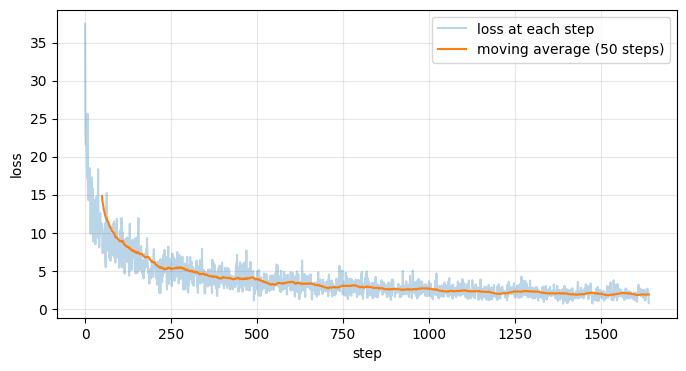

In [120]:
import numpy as np
import matplotlib.pyplot as plt

window = 50
smooth = np.convolve(lossi, np.ones(window) / window, mode="valid")

plt.figure(figsize=(8, 4))
plt.plot(lossi, alpha=0.3, label="loss at each step")
plt.plot(np.arange(window - 1, len(lossi)), smooth, label=f"moving average ({window} steps)")
plt.xlabel("step")
plt.ylabel("loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [121]:
with torch.no_grad():
    emb = C[X_train]
    h = torch.tanh(emb.view(-1, input_size) @ W1 + b1)
    logits = h @ W2 + b2
    val_loss = F.cross_entropy(logits, Y_train)

print("Train loss:", val_loss.item())

Train loss: 1.813076376914978


In [122]:
with torch.no_grad():
    emb = C[X_valid]
    h = torch.tanh(emb.view(-1, input_size) @ W1 + b1)
    logits = h @ W2 + b2
    val_loss = F.cross_entropy(logits, Y_valid)

print("Validation loss:", val_loss.item())

Validation loss: 3.889681816101074


In [123]:
# sample from the model
g = torch.Generator().manual_seed(SEED)

for _ in range(20):
    
    out = []
    context = [0] * window_size
    while True:
      emb = C[torch.tensor([context])]
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(num_to_char[i] for i in out))

անիկյան.
ավագիխասադալյան.
ադայան.
ազնանասագիթյան.
ազնաջյան.
ամազյան.
ասոյան.
ադաթանյան.
անկանյան.
ադալյան.
անտիկյան.
անկանյան.
աղունց.
անտյան.
ենվելանյան.
գազանեսյան.
աբիկյան.
ավաավագիլումանասանասագիլաբեջլոյան.
աթշանասաջասանայան.
ասդարումանյան.
